# Part 3: Real Object Localization (Generalized Hough Transform)

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Helper for execution profiling
def profile_time(start_time, part_name):
    elapsed = time.time() - start_time
    print(f"Execution time for {part_name}: {elapsed:.4f} seconds")

## 1. Helper Functions (Vectorized Convolution & Edge Detection)

In [32]:
def vectorized_conv2d_3x3(img, kernel):
    """
    Perform 2D convolution with a 3x3 kernel using NumPy array slicing.
    This fully avoids Python spatial loops and satisfies the vectorization requirement.
    """
    h, w = img.shape
    padded = np.pad(img, pad_width=1, mode='constant', constant_values=0)
    output = np.zeros((h, w), dtype=np.float64)
    
    # Vectorized computation across the entire image
    # Only loops over the 3x3 kernel dimensions (9 iterations = O(1))
    for i in range(3):
        for j in range(3):
            output += padded[i:i+h, j:j+w] * kernel[i, j]
            
    return output

def compute_edges_and_gradients(img, threshold=50):
    """
    Compute edge magnitude and gradient direction using Sobel operators from scratch.
    """
    # Sobel kernels
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
    
    # Convolution from scratch
    Gx = vectorized_conv2d_3x3(img, Kx)
    Gy = vectorized_conv2d_3x3(img, Ky)
    
    # Magnitude and Direction (phi in radians)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    phi = np.arctan2(Gy, Gx) # Returns values between -pi and pi
    
    # Thresholding to obtain edge map
    edge_map = (magnitude > threshold).astype(np.uint8)
    
    return edge_map, Gx, Gy, magnitude, phi

## 2. Load Images and Preprocessing

In [33]:
# File Paths
template_path = 'images/object_localization/template_flower_gray.png'
test_color_path = 'images/object_localization/test_flower_original.jpg'

start_time = time.time()

# Load images (cv2.imread is explicitly allowed)
template_img = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
test_color_img = cv2.imread(test_color_path, cv2.IMREAD_COLOR)

# Conversions (cv2.cvtColor is explicitly allowed for basic color space conversions)
test_rgb = cv2.cvtColor(test_color_img, cv2.COLOR_BGR2RGB)
test_gray = cv2.cvtColor(test_color_img, cv2.COLOR_BGR2GRAY)

# Cast to float for mathematical opertaions
template_img_f = template_img.astype(np.float64)
test_gray_f = test_gray.astype(np.float64)

# Set an appropriate edge threshold
edge_thresh = 150 

# Compute Edges for Template and Test images
template_edge_map, _, _, template_mag, template_phi = compute_edges_and_gradients(template_img_f, threshold=edge_thresh)
test_edge_map, _, _, test_mag, test_phi = compute_edges_and_gradients(test_gray_f, threshold=edge_thresh)

profile_time(start_time, "Preprocessing & Edge Detection")

Execution time for Preprocessing & Edge Detection: 0.9730 seconds


## 3. $\phi$-Table (R-Table) Construction

In [34]:
def build_r_table_vectorized(edge_map, phi, num_bins=180):
    """
    Build the R-Table for the Generalized Hough Transform.
    """
    # Reference point: center of the template
    yc, xc = edge_map.shape[0] // 2, edge_map.shape[1] // 2
    r_table = {i: [] for i in range(num_bins)}
    
    # Extract only valid edge pixels
    edges_y, edges_x = np.nonzero(edge_map)
    angles = phi[edges_y, edges_x]
    
    # Binning angle: mapping [-pi, pi] to [0, num_bins-1]
    phi_binned = np.floor((angles + np.pi) / (2 * np.pi) * num_bins).astype(int)
    phi_binned = np.clip(phi_binned, 0, num_bins - 1)
    
    # Calculate displacement vectors from the edge points to the reference center
    dy = yc - edges_y
    dx = xc - edges_x
    
    # Build dictionary map
    for b, y, x in zip(phi_binned, dy, dx):
        r_table[b].append((y, x))
        
    # Convert lists to NumPy arrays for faster vectorized broadcast processing later
    for k in r_table:
        r_table[k] = np.array(r_table[k])
        if r_table[k].shape[0] == 0:
            r_table[k] = np.empty((0, 2), dtype=int)
            
    return r_table, xc, yc

start_time = time.time()
num_gradient_bins = 180
r_table, template_xc, template_yc = build_r_table_vectorized(template_edge_map, template_phi, num_bins=num_gradient_bins)
profile_time(start_time, "R-Table Construction")

Execution time for R-Table Construction: 0.3075 seconds


## 4. Generalized Hough Voting

In [35]:
def generalized_hough_voting_vectorized(test_edge_map, test_phi, r_table, num_bins=180):
    """
    Apply voting to the test image using the fully vectorized array operations.
    """
    h, w = test_edge_map.shape
    accumulator = np.zeros((h, w), dtype=np.float64)
    
    # Extract only valid edge pixels
    edges_y, edges_x = np.nonzero(test_edge_map)
    angles = test_phi[edges_y, edges_x]
    
    # Binning angle mapping
    phi_binned = np.floor((angles + np.pi) / (2 * np.pi) * num_bins).astype(int)
    phi_binned = np.clip(phi_binned, 0, num_bins - 1)
    
    # Iterate dynamically only over bins that actually exist in the image
    unique_bins = np.unique(phi_binned)
    
    for b in unique_bins:
        offsets = r_table.get(b, np.empty((0, 2)))
        
        # Skip if no template vectors mapping for this direction
        if offsets.shape[0] == 0:
            continue
            
        mask = (phi_binned == b)
        y_b = edges_y[mask] # Shape: (M,)
        x_b = edges_x[mask] # Shape: (M,)
        
        dy = offsets[:, 0] # Shape: (N,)
        dx = offsets[:, 1] # Shape: (N,)
        
        # Heavy NumPy Vectorization (Broadcasting)
        # Calculates all (y+dy, x+dx) combinations without loops
        # votes_y shape: (M, N) expanded and unraveled to 1D
        votes_y = (y_b[:, None] + dy[None, :]).ravel()
        votes_x = (x_b[:, None] + dx[None, :]).ravel()
        
        # Filter strictly out of bounds votes
        valid = (votes_y >= 0) & (votes_y < h) & (votes_x >= 0) & (votes_x < w)
        
        # Fast direct array 2D accumulation mapping
        np.add.at(accumulator, (votes_y[valid], votes_x[valid]), 1)
        
    return accumulator

start_time = time.time()
accumulator = generalized_hough_voting_vectorized(test_edge_map, test_phi, r_table, num_bins=num_gradient_bins)
profile_time(start_time, "Generalized Hough Voting")

Execution time for Generalized Hough Voting: 0.7027 seconds


## 5. Object Localization & Visualization

Target object estimated center localized at: (x=953, y=884)


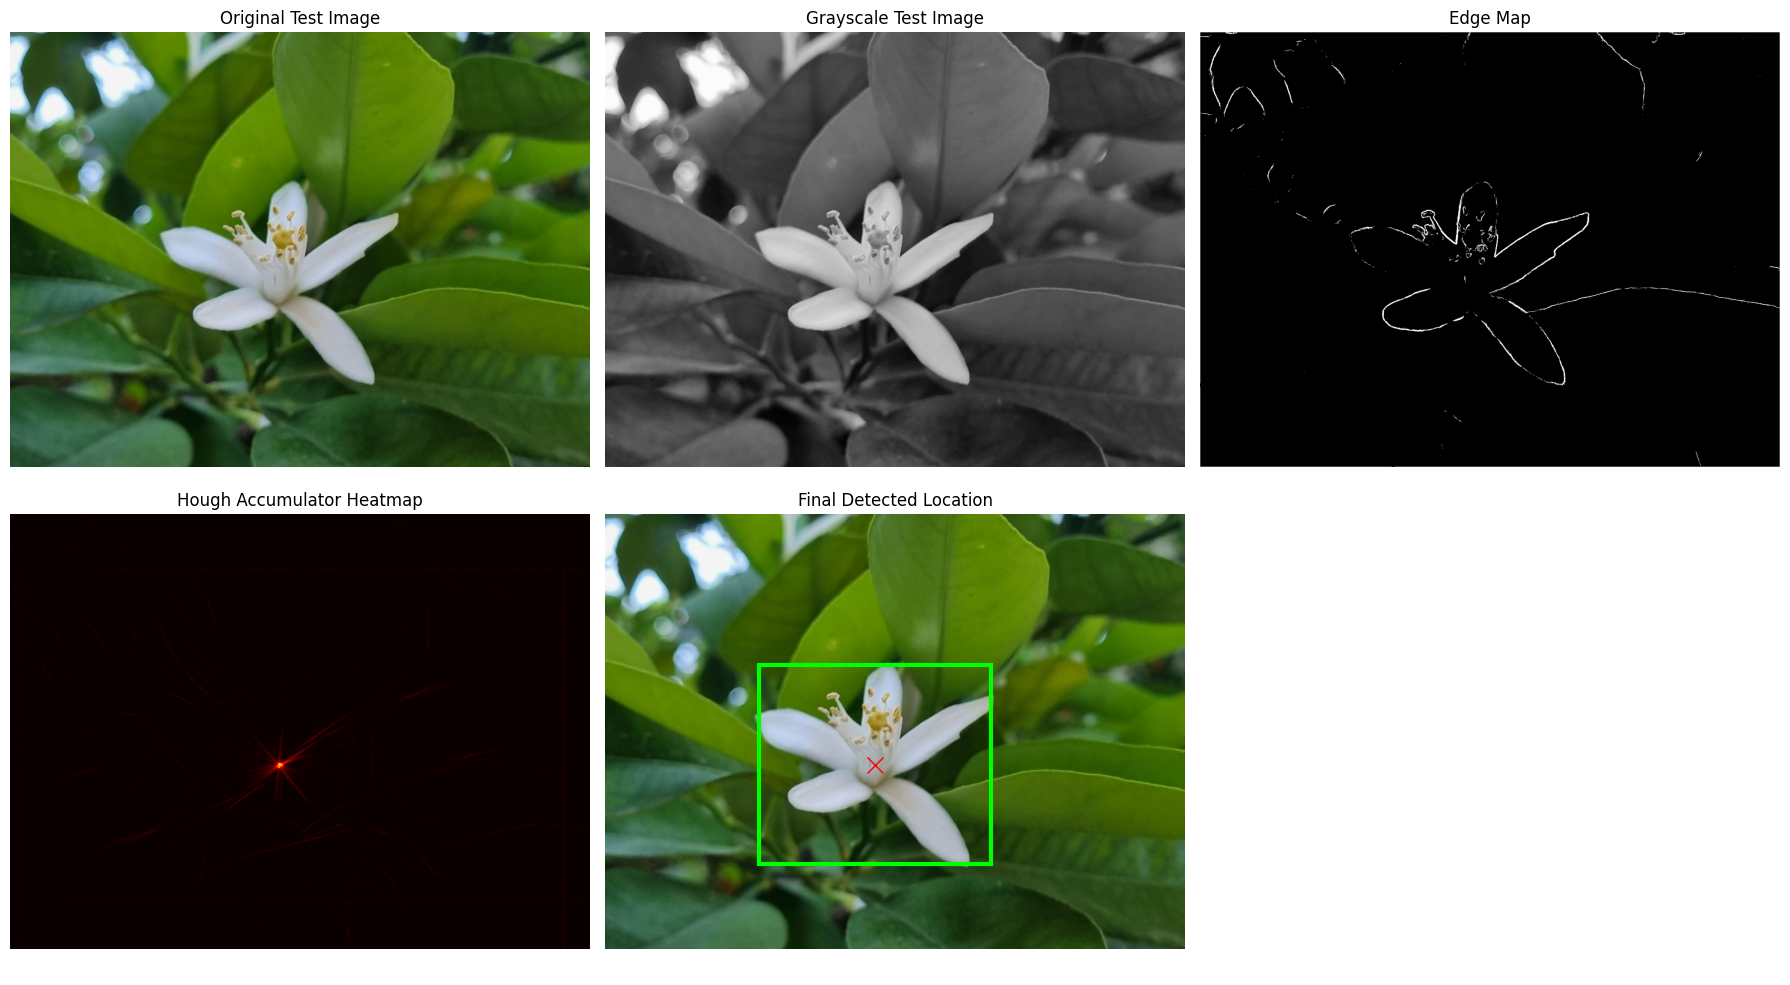

In [36]:
# Peak Detection
max_idx = np.argmax(accumulator)
est_yc, est_xc = np.unravel_index(max_idx, accumulator.shape)

print(f"Target object estimated center localized at: (x={est_xc}, y={est_yc})")

# Constructing visual deliverables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# 1. Original Test Image 
axes[0].imshow(test_rgb)
axes[0].set_title("Original Test Image")
axes[0].axis('off')

# 2. Grayscale Test Image
axes[1].imshow(test_gray, cmap='gray')
axes[1].set_title("Grayscale Test Image")
axes[1].axis('off')

# 3. Edge Map
axes[2].imshow(test_edge_map, cmap='gray')
axes[2].set_title("Edge Map")
axes[2].axis('off')

# 4. Hough Accumulator Heatmap
axes[3].imshow(accumulator, cmap='hot')
axes[3].set_title("Hough Accumulator Heatmap")
axes[3].axis('off')

# 5. Final Detected Location
axes[4].imshow(test_rgb.copy())
axes[4].set_title("Final Detected Location")
axes[4].axis('off')

# Draw bounding box identifying the scaled template size match and center
th, tw = template_edge_map.shape
top_left_x = est_xc - template_xc
top_left_y = est_yc - template_yc
rect = plt.Rectangle((top_left_x, top_left_y), tw, th, edgecolor='lime', facecolor='none', linewidth=3)
axes[4].add_patch(rect)
axes[4].plot(est_xc, est_yc, 'rx', markersize=12, linewidth=3) # Highlight Peak Location

axes[5].axis('off') # Hide unused final subplot

plt.tight_layout()
plt.show()

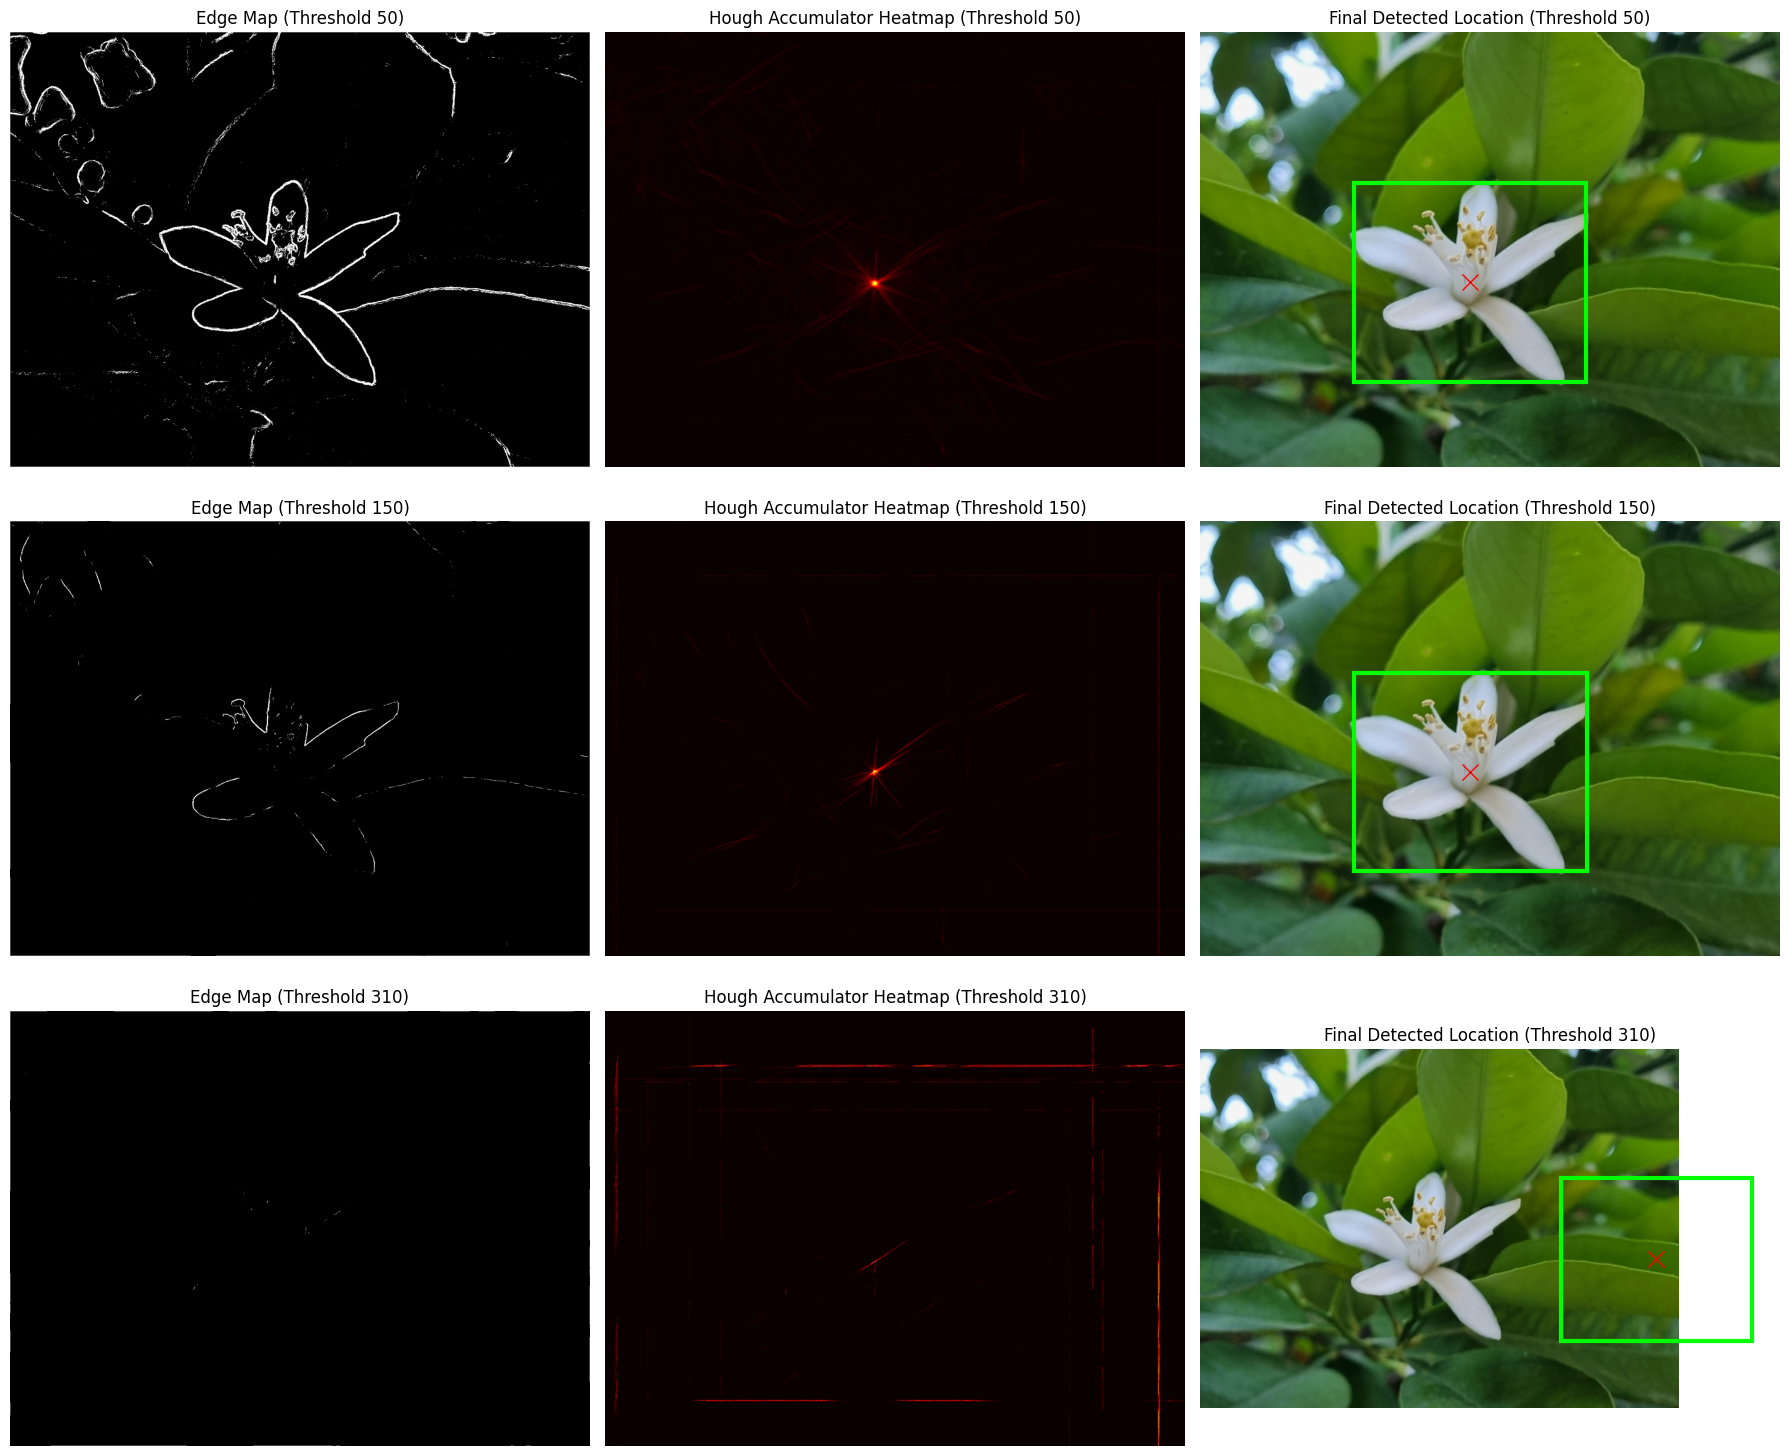

In [44]:
# Testing Edge Thresholds [100, 150, 200]
test_thresholds = [50, 150, 310]
num_gradient_bins = 180

fig, axes = plt.subplots(len(test_thresholds), 3, figsize=(18, 5 * len(test_thresholds)))

for i, test_th in enumerate(test_thresholds):
    # 1. Edge Detection
    temp_edge_map, _, _, _, temp_phi = compute_edges_and_gradients(template_img_f, threshold=test_th)
    tst_edge_map, _, _, _, tst_phi = compute_edges_and_gradients(test_gray_f, threshold=test_th)
    
    # 2. R-Table Construction
    r_tab, t_xc, t_yc = build_r_table_vectorized(temp_edge_map, temp_phi, num_bins=num_gradient_bins)
    
    # 3. Generalized Hough Voting
    accum = generalized_hough_voting_vectorized(tst_edge_map, tst_phi, r_tab, num_bins=num_gradient_bins)
    
    # 4. Localization
    max_id = np.argmax(accum)
    e_yc, e_xc = np.unravel_index(max_id, accum.shape)
    
    # 5. Visualizations
    
    # Edge Map
    axes[i, 0].imshow(tst_edge_map, cmap='gray')
    axes[i, 0].set_title(f"Edge Map (Threshold {test_th})")
    axes[i, 0].axis('off')
    
    # Accumulator Heatmap
    axes[i, 1].imshow(accum, cmap='hot')
    axes[i, 1].set_title(f"Hough Accumulator Heatmap (Threshold {test_th})")
    axes[i, 1].axis('off')
    
    # Final Detected Location
    axes[i, 2].imshow(test_rgb.copy())
    axes[i, 2].set_title(f"Final Detected Location (Threshold {test_th})")
    axes[i, 2].axis('off')
    
    if accum.max() > 0:
        t_h, t_w = temp_edge_map.shape
        t_l_x = e_xc - t_xc
        t_l_y = e_yc - t_yc
        rect_patch = plt.Rectangle((t_l_x, t_l_y), t_w, t_h, edgecolor='lime', facecolor='none', linewidth=3)
        axes[i, 2].add_patch(rect_patch)
        axes[i, 2].plot(e_xc, e_yc, 'rx', markersize=12, linewidth=3)

plt.tight_layout()
plt.show()